### Biblioteki

In [2]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt

In [4]:
from src.music_dataset.MusicDataset import MusicDataset
from src.utils.load_data import load_data
from src.utils.map_data import map_label_to_name, map_name_to_label
from src.utils.visualize import plot_label_distribution
from src.models.load_data import split_data, create_dataset, get_sampler, create_dataloader

### Ścieżki do plików

In [5]:
TEST_DATA = 'data/test_no_target.pkl'
TRAIN_DATA = 'data/train.pkl'

In [6]:
train_data = load_data(TRAIN_DATA)
test_data = load_data(TEST_DATA)

### Dataset

In [14]:
BOUNDRY = 1024
PAD_VALUE = 0.0

full_given_dataset = MusicDataset(train_data, BOUNDRY, PAD_VALUE)

In [8]:
longest_seq = max(len(seq_label[0]) for seq_label in train_data)
print(f"Longest sequence length in training data: {longest_seq}")

avg_seq_len = np.mean([len(seq_label[0]) for seq_label in train_data])
print(f"Average sequence length in training data: {avg_seq_len:.2f}")

num_of_sequences_longer_than_boundry = sum(1 for seq_label in train_data if len(seq_label[0]) > BOUNDRY)
print(f"Number of sequences longer than 500 in training data: {num_of_sequences_longer_than_boundry}")

num_of_sequences_shorter_than_boundry= sum(1 for seq_label in train_data if len(seq_label[0]) <= BOUNDRY)
print(f"Number of sequences shorter than 500 in training data: {num_of_sequences_shorter_than_boundry}")


Longest sequence length in training data: 6308
Average sequence length in training data: 436.50
Number of sequences longer than 500 in training data: 265
Number of sequences shorter than 500 in training data: 2674


In [9]:
def show_random_sequence(dataset):
    index = np.random.randint(0, len(dataset) - 1)
    seq, label = dataset[index]
    print(f"Sequence {index}:")
    print(f"Label: {label}")
    print(f"Sequence length: {len(seq)}")
    print(f"Sequence data: {seq}")

In [15]:
show_random_sequence(full_given_dataset)

Sequence 2777:
Label: 4
Sequence length: 1024
Sequence data: tensor([ -1.,  80., 162.,  ...,   0.,   0.,   0.])


### Analiza danych

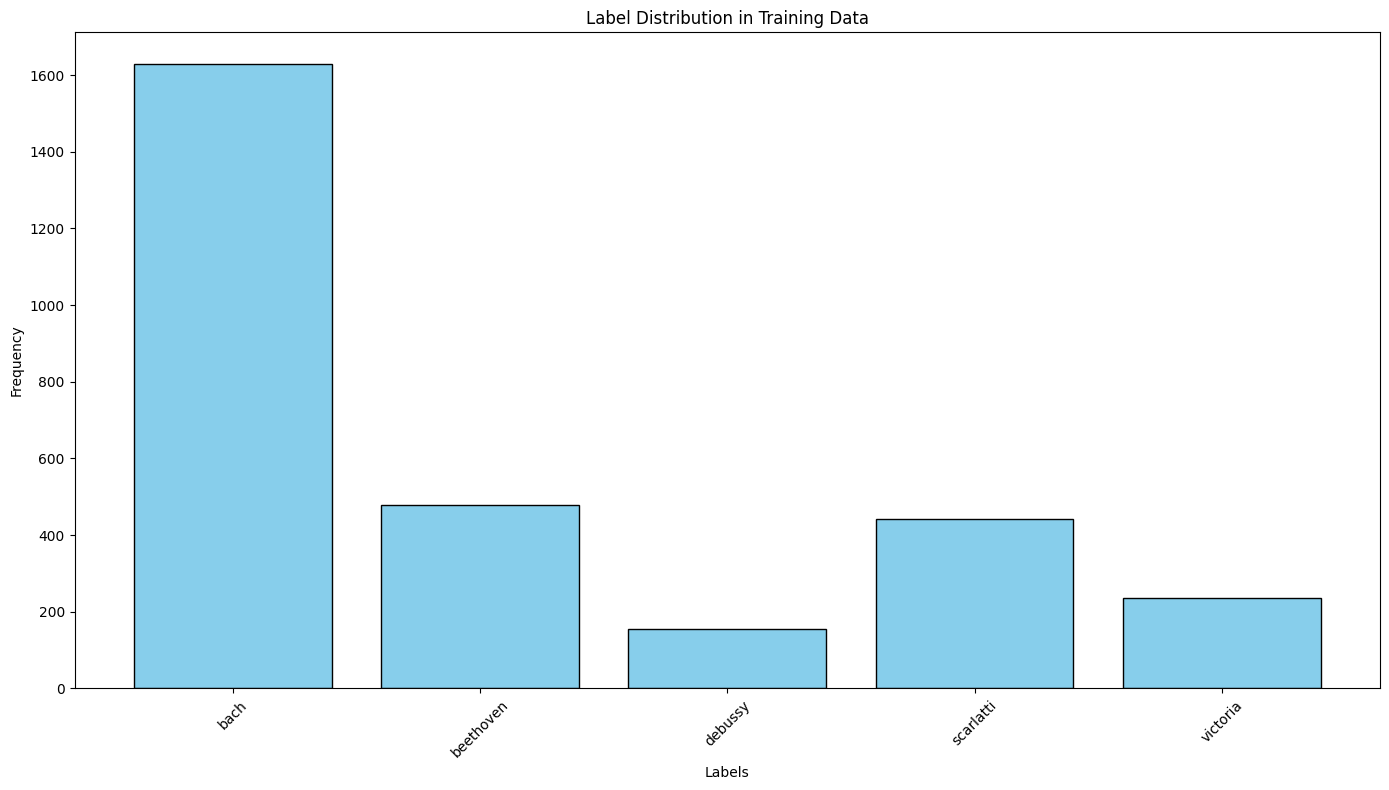

bach: 1630 (55.46%)
beethoven: 478 (16.26%)
debussy: 154 (5.24%)
scarlatti: 441 (15.01%)
victoria: 236 (8.03%)


In [16]:
plot_label_distribution(full_given_dataset, "Label Distribution in Training Data")

### Split danych

In [17]:
x_train, y_train, x_val, y_val, x_test, y_test = split_data(train_data, 0.7)

train_dataset = create_dataset(x_train, y_train, BOUNDRY, PAD_VALUE)
val_dataset = create_dataset(x_val, y_val, BOUNDRY, PAD_VALUE)
test_dataset = create_dataset(x_test, y_test, BOUNDRY, PAD_VALUE)


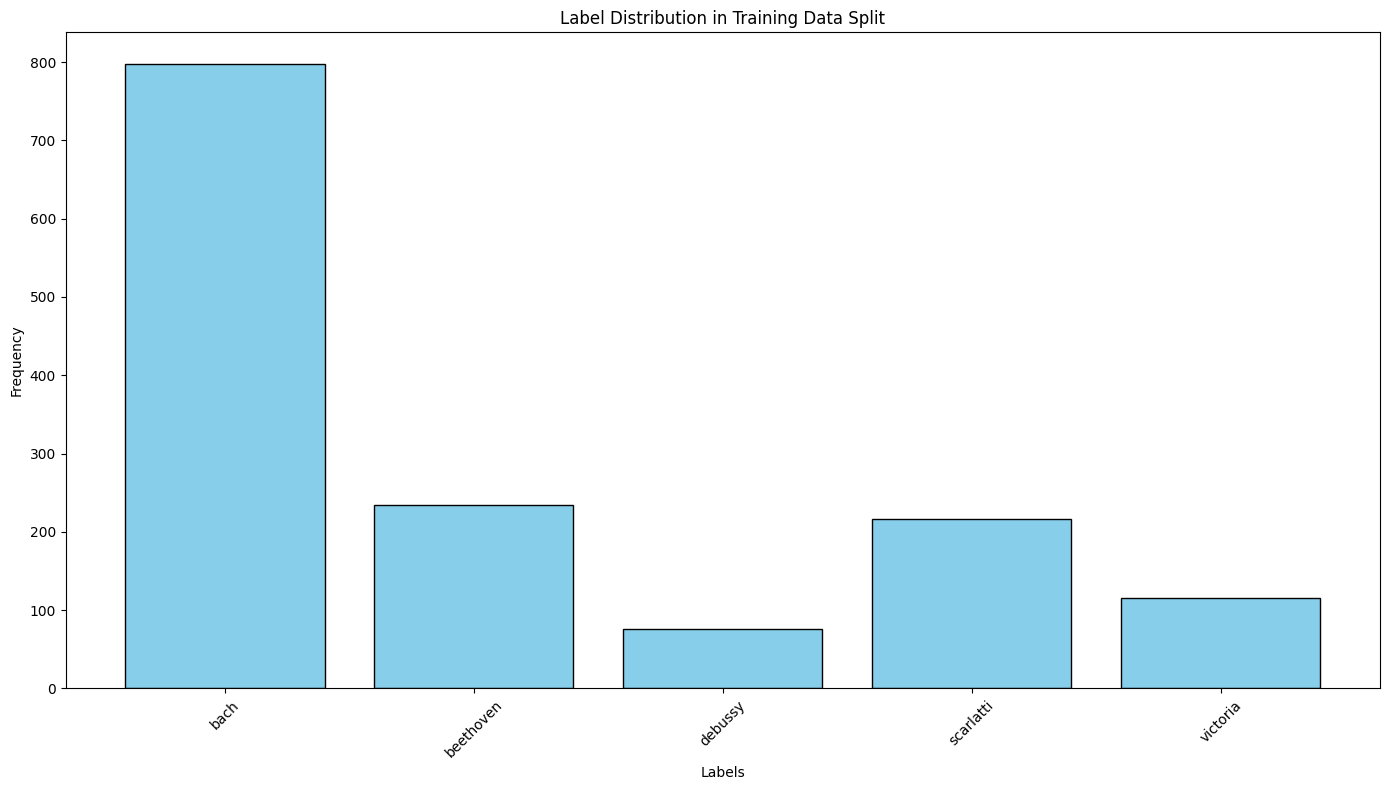

bach: 798 (55.46%)
beethoven: 234 (16.26%)
debussy: 76 (5.28%)
scarlatti: 216 (15.01%)
victoria: 115 (7.99%)


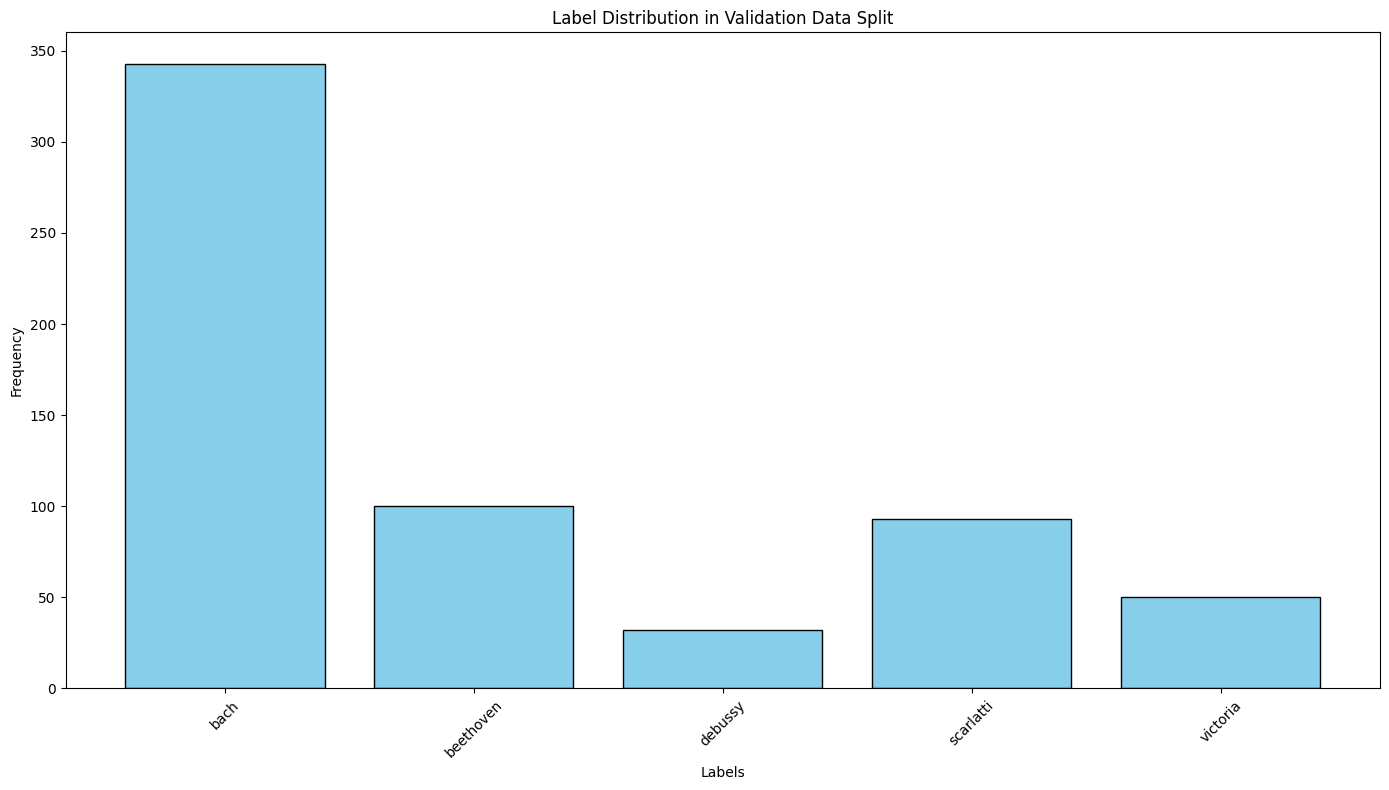

bach: 343 (55.50%)
beethoven: 100 (16.18%)
debussy: 32 (5.18%)
scarlatti: 93 (15.05%)
victoria: 50 (8.09%)


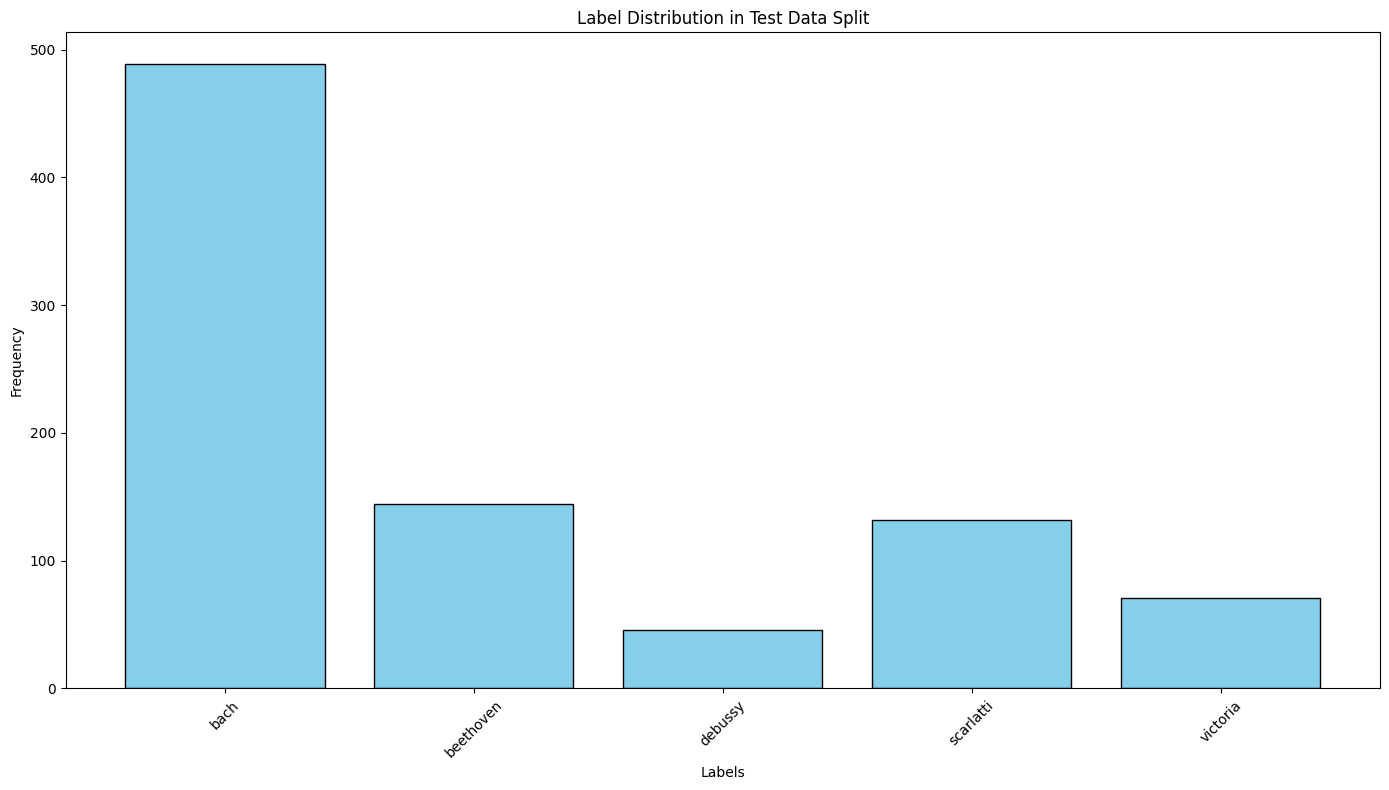

bach: 489 (55.44%)
beethoven: 144 (16.33%)
debussy: 46 (5.22%)
scarlatti: 132 (14.97%)
victoria: 71 (8.05%)


In [18]:
plot_label_distribution(train_dataset, "Label Distribution in Training Data Split")
plot_label_distribution(val_dataset, "Label Distribution in Validation Data Split")
plot_label_distribution(test_dataset, "Label Distribution in Test Data Split")